# Exploring the NAQFC O3 forecast datacube

In [1]:
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# The store, matching ICECHUNK_BUCKET_NAME / ICECHUNK_PREFIX in .env
STORE_BUCKET = "airquality-data-store-develop"
STORE_PREFIX = "naqfc/aqmv7/o3_conus"
STORE_REGION = "us-west-2"

# Where the virtual chunks actually live
SOURCE_PREFIX = "s3://noaa-nws-naqfc-pds/"

## Open the store

Two different credential scopes are in play:

- **Your IAM credentials** (`from_env=True`) read the Icechunk metadata — snapshots, manifests,
  coordinates — out of your own bucket.
- **Anonymous credentials** read the referenced GRIB messages out of NOAA's public bucket.
  Without these every chunk read fails when fetching individual chunks from the orignal files.

The *container* declaration — which URL prefix is virtual and how to reach it — was written into
the repository when the store was created, so it travels with the repo and a reader doesn't
redeclare it. Only the credentials, which are never persisted, have to be supplied here.

In [2]:
repo = icechunk.Repository.open(
    storage=icechunk.s3_storage(
        bucket=STORE_BUCKET,
        prefix=STORE_PREFIX,
        region=STORE_REGION,
        from_env=True,
    ),
    authorize_virtual_chunk_access=icechunk.containers_credentials(
        {SOURCE_PREFIX: icechunk.s3_anonymous_credentials()}
    ),
)

print("branches:            ", repo.list_branches())
print("virtual containers:  ", list(repo.config.virtual_chunk_containers))
print("commits on main:     ", sum(1 for _ in repo.ancestry(branch="main")))

branches:             {'backfill', 'main'}
virtual containers:   ['s3://noaa-nws-naqfc-pds/']
commits on main:      6


In [3]:
cube = xr.open_zarr(
    repo.readonly_session("main").store, consolidated=False, zarr_format=3
)

# The store deliberately carries no valid_time: it is exactly
# reference_time + lead, so storing it would duplicate a 2-D coordinate that
# every append then has to keep in step. Attach it once here and it rides along
# through every isel below, so nothing downstream has to re-derive it.
# Both operands must stay DataArrays -- mixing in a raw ndarray
# (cube.lead.values) has no dimension to align on and fails to broadcast.
cube = cube.assign_coords(
    valid_time=cube.reference_time + cube.lead.astype("timedelta64[h]")
)

cube

<xarray.Dataset> Size: 1TB
Dimensions:         (reference_time: 1696, lead: 72, y: 1025, x: 1473)
Coordinates:
  * reference_time  (reference_time) datetime64[ns] 14kB 2024-05-14T06:00:00 ...
  * lead            (lead) int32 288B 1 2 3 4 5 6 7 8 ... 66 67 68 69 70 71 72
  * y               (y) float64 8kB -8.327e+05 -8.276e+05 ... 4.368e+06
  * x               (x) float64 12kB -4.226e+06 -4.221e+06 ... 3.25e+06
    spatial_ref     int64 8B 0
    longitude       (y, x) float64 12MB ...
    latitude        (y, x) float64 12MB ...
    valid_time      (reference_time, lead) datetime64[ns] 977kB 2024-05-14T07...
Data variables:
    ozcon           (reference_time, lead, y, x) float64 1TB ...
Attributes:
    meta:     Generated with gribberishpy

### Verify that our reference_time sort order is correct.

In [10]:
cube.indexes["reference_time"].is_monotonic_increasing and cube.indexes["reference_time"].is_unique

True

## Why there is no 1-d time dimension

NAQFC runs twice a day and each run forecasts 72 hours ahead, so successive cycles re-forecast
most of the same wall-clock hours with different values. A flat `time` axis would give duplicate labels and no way to say which forecast run a value came
from.

Using **`reference_time`** (when the model was initialized) × **`lead`** (hours
ahead) makes every element unique by construction. This is also what lets the backfill write
thousands of files concurrently: each cycle owns a disjoint region, so parallel workers never
contend for the same chunk.

Valid time is not stored — it is exactly `reference_time + lead`, so keeping it would mean
maintaining a redundant 2-D coordinate on every append. It is derived above in one line.

In [4]:
n_ref, n_lead = cube.sizes["reference_time"], cube.sizes["lead"]
logical_gb = cube["ozcon"].nbytes / 1e9

first, last = cube.reference_time.values[0], cube.reference_time.values[-1]
print(f"cycles span {np.datetime64(first, 'h')} .. {np.datetime64(last, 'h')}")

# The 06z and 12z runs of a day overlap in valid time
shared = np.intersect1d(cube.valid_time.values[0], cube.valid_time.values[1])
print(f"valid times shared by the first two cycles: {len(shared)} of {n_lead}")

cycles span 2024-05-14T06 .. 2026-09-08T12
valid times shared by the first two cycles: 66 of 72


## Read one forecast field

One ranged GET for a single GRIB message, decoded on read
by the `gribberish` codec. Chunks span the full grid, so any read touching one point still pulls
that whole message (~1.2 MB compressed, ~12 MB decoded).

In [5]:
REF, LEAD = -1, 0  # most recent cycle, +1 h

ozcon = cube["ozcon"].isel(reference_time=REF, lead=LEAD).load()
init = np.datetime64(cube.reference_time.values[REF], "h")
valid = cube.valid_time.values[REF, LEAD]

print(f"Initialized {init}, +{int(cube.lead.values[LEAD])} h -> valid {valid}")
print(
    f"Ozone ppb: min={np.nanmin(ozcon.values):.2f} "
    f"mean={np.nanmean(ozcon.values):.2f} max={np.nanmax(ozcon.values):.2f}"
)

Initialized 2026-09-08T12, +1 h -> valid 2026-09-08T13:00:00.000000000
Ozone ppb: min=0.58 mean=29.88 max=53.94


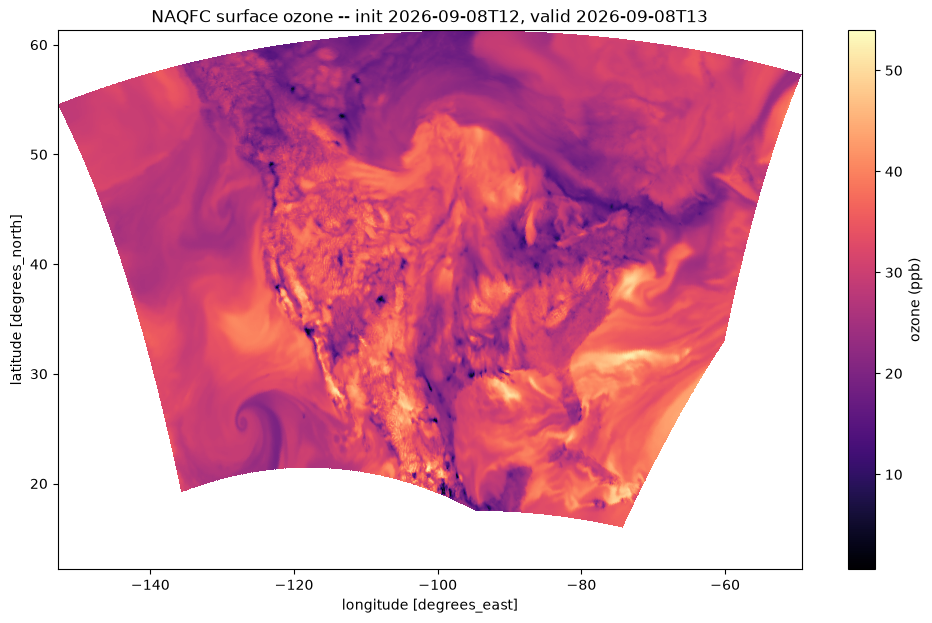

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))
ozcon.plot(
    x="longitude",
    y="latitude",
    cmap="magma",
    ax=ax,
    cbar_kwargs={"label": "ozone (ppb)"},
)
ax.set_title(f"NAQFC surface ozone -- init {init}, valid {np.datetime64(valid, 'h')}")
plt.show()

## How are forecasts changing as we approach the forecasted time?

Because every run's view is retained rather than overwritten, you can ask a question a flat
time series cannot answer: **how did successive forecasts of the same hour change as that hour
got closer?**

Each point below is a different model run's prediction for one fixed valid time, plotted against
how far ahead it was forecasting.

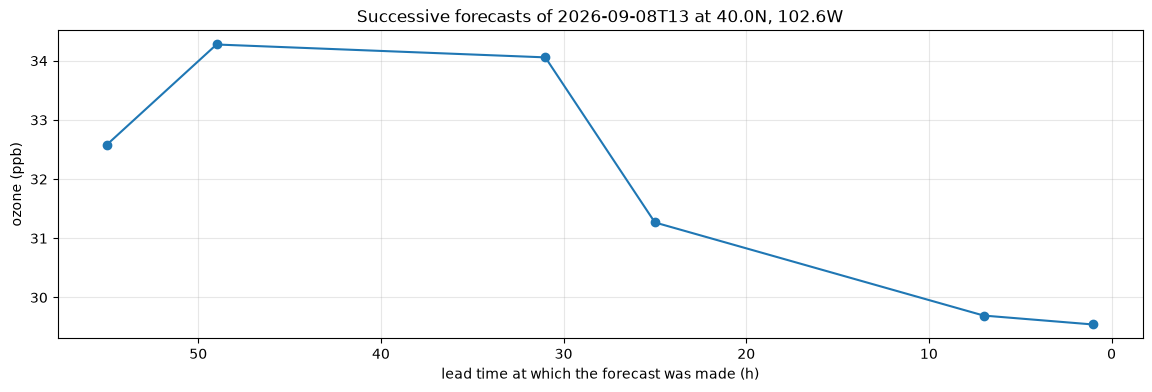

In [7]:
PY, PX = 500, 700  # 40.0 N, 102.6 W -- eastern Colorado

# Every (reference_time, lead) pair that forecast this same valid time.
target = cube.valid_time.values[-1, 0]
r, l = np.nonzero(cube.valid_time.values == target)
forecasts = cube["ozcon"].isel(
    reference_time=xr.DataArray(r, dims="forecast"),
    lead=xr.DataArray(l, dims="forecast"),
    y=PY, x=PX,
).sortby("lead")

fig, ax = plt.subplots(figsize=(14, 4))
# plot.line rather than plot: the generic .plot() squeezes size-1 dimensions
# before dispatching, so a valid time forecast by only one cycle -- the first
# cycle in the store, or one isolated by a gap -- collapses to a scalar and
# raises "No numeric data to plot".
forecasts.plot.line(x="lead", marker="o", ax=ax)
ax.invert_xaxis()  # time runs left to right as lead shrinks
ax.set_xlabel("lead time at which the forecast was made (h)")
ax.set_ylabel("ozone (ppb)")
ax.set_title(f"Successive forecasts of {np.datetime64(target, 'h')} at 40.0N, 102.6W")
ax.grid(alpha=0.3)
plt.show()

## How is the forecasted value changing with lead time?
For a single reference time, how does the forecast differ acros lead times.

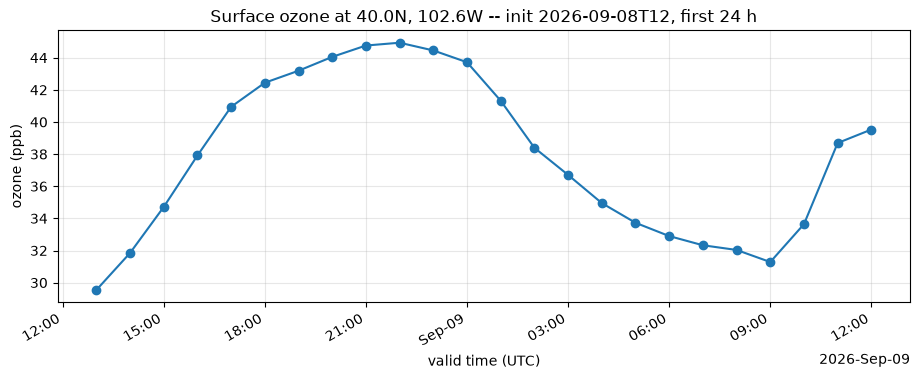

In [8]:
N_LEADS = 24

series = cube["ozcon"].isel(
    reference_time=REF, lead=slice(0, N_LEADS), y=PY, x=PX
)

fig, ax = plt.subplots(figsize=(11, 4))
series.plot(x="valid_time", marker="o", ax=ax)
ax.set_xlabel("valid time (UTC)")
ax.set_ylabel("ozone (ppb)")
ax.set_title(f"Surface ozone at 40.0N, 102.6W -- init {init}, first {N_LEADS} h")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.show()